# 1. Objective of Advanced Modeling

The objective of this notebook is to develop a stronger fraud detection model using XGBoost.

After establishing baseline performance with Logistic Regression and Random Forest in the previous notebook, this notebook focuses on building a more advanced model that can better handle complex feature relationships and improve fraud detection performance.

XGBoost is selected because it is a powerful ensemble learning algorithm that performs very well on structured tabular data and is widely used in real-world machine learning applications.

In this notebook, the following tasks are performed:

- Train an initial XGBoost model
- Handle class imbalance using suitable techniques
- Tune important hyperparameters
- evaluate the tuned model on the validation/test set
- Explore threshold tuning for fraud detection trade-offs
- Select and save the best XGBoost model for later use in explainability and deployment

The final output of this notebook will be the best-performing XGBoost model for the project.

# 2. Import Libraries

In this section, the required libraries for XGBoost modeling, hyperparameter tuning, evaluation, and model saving are imported.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

# 3. Load Preprocessed Data

The processed datasets prepared in Notebook 2 are loaded here.

For advanced modeling, two training strategies can be explored:

1. Use the original training data with class imbalance and apply `scale_pos_weight`
2. Use the SMOTE-resampled training data

In this notebook, both approaches are prepared so that performance can be compared.

The test set remains unchanged and is used for fair evaluation.

In [29]:
X_train_scaled = pd.read_csv("../data/processed/X_train_scaled.csv")
X_test_scaled = pd.read_csv("../data/processed/X_test_scaled.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

X_train_resampled = pd.read_csv("../data/processed/X_train_resampled.csv")
y_train_resampled = pd.read_csv("../data/processed/y_train_resampled.csv").squeeze()

print("Original training shape:", X_train_scaled.shape)
print("Original test shape:", X_test_scaled.shape)
print("Resampled training shape:", X_train_resampled.shape)
print("Test labels shape:", y_test.shape)

Original training shape: (227845, 30)
Original test shape: (56962, 30)
Resampled training shape: (454902, 30)
Test labels shape: (56962,)


In [30]:
print("Original training class distribution:")
print(y_train.value_counts())

print("\nResampled training class distribution:")
print(y_train_resampled.value_counts())

Original training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Resampled training class distribution:
Class
0    227451
1    227451
Name: count, dtype: int64


# 4. Why XGBoost for This Project

XGBoost is selected as the main advanced model for this project for several reasons:

1. It performs very well on structured tabular datasets
2. It can model nonlinear feature interactions more effectively than Logistic Regression
3. It often outperforms many traditional machine learning algorithms on classification tasks
4. It includes regularization, which helps reduce overfitting
5. It supports class imbalance handling through `scale_pos_weight`
6. It can produce probability outputs that are useful for fraud scoring and threshold tuning
7. It is compatible with SHAP, which will be used later for explainability

Because credit card fraud detection involves complex patterns, class imbalance, and the need for probability-based decisions, XGBoost is a strong fit for this project.

# 5. Initial XGBoost Model

An initial XGBoost model is trained using default or near-default settings to establish a starting benchmark before tuning.

This helps us understand the model's initial performance and provides a reference point for later improvements.

In [31]:
xgb_initial = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)

xgb_initial.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [32]:
y_pred_xgb_initial = xgb_initial.predict(X_test_scaled)
y_prob_xgb_initial = xgb_initial.predict_proba(X_test_scaled)[:, 1]

In [33]:
initial_results = {
    "Model": "Initial XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_xgb_initial),
    "Precision": precision_score(y_test, y_pred_xgb_initial, zero_division=0),
    "Recall": recall_score(y_test, y_pred_xgb_initial, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_xgb_initial, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb_initial),
    "PR-AUC": average_precision_score(y_test, y_prob_xgb_initial)
}

pd.DataFrame([initial_results])

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Initial XGBoost,0.999438,0.866667,0.795918,0.829787,0.938952,0.797291


# 6. Handling Imbalance in XGBoost

Class imbalance is a major challenge in fraud detection because fraudulent transactions are very rare compared to legitimate ones.

For XGBoost, two main imbalance handling approaches are considered:

## Approach 1: `scale_pos_weight`
This method increases the penalty for misclassifying minority fraud cases by adjusting the positive class weight.

## Approach 2: SMOTE-resampled training data
This method uses the balanced training dataset generated in Notebook 2.

Both approaches are valid, and their performance can be compared to determine which one works better for this project.

In [34]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count

print("Negative class count:", neg_count)
print("Positive class count:", pos_count)
print("scale_pos_weight:", scale_pos_weight_value)

Negative class count: 227451
Positive class count: 394
scale_pos_weight: 577.2868020304569


In [35]:
xgb_weighted = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight_value
)

xgb_weighted.fit(X_train_scaled, y_train)

y_pred_xgb_weighted = xgb_weighted.predict(X_test_scaled)
y_prob_xgb_weighted = xgb_weighted.predict_proba(X_test_scaled)[:, 1]

weighted_results = {
    "Model": "XGBoost (scale_pos_weight)",
    "Accuracy": accuracy_score(y_test, y_pred_xgb_weighted),
    "Precision": precision_score(y_test, y_pred_xgb_weighted, zero_division=0),
    "Recall": recall_score(y_test, y_pred_xgb_weighted, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_xgb_weighted, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb_weighted),
    "PR-AUC": average_precision_score(y_test, y_prob_xgb_weighted)
}

pd.DataFrame([weighted_results])

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,XGBoost (scale_pos_weight),0.999526,0.88172,0.836735,0.858639,0.968238,0.880004


In [36]:
xgb_smote = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)

xgb_smote.fit(X_train_resampled, y_train_resampled)

y_pred_xgb_smote = xgb_smote.predict(X_test_scaled)
y_prob_xgb_smote = xgb_smote.predict_proba(X_test_scaled)[:, 1]

smote_results = {
    "Model": "XGBoost (SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_xgb_smote),
    "Precision": precision_score(y_test, y_pred_xgb_smote, zero_division=0),
    "Recall": recall_score(y_test, y_pred_xgb_smote, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_xgb_smote, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb_smote),
    "PR-AUC": average_precision_score(y_test, y_prob_xgb_smote)
}

pd.DataFrame([smote_results])

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,XGBoost (SMOTE),0.999192,0.72807,0.846939,0.783019,0.979983,0.868282


# 7. Hyperparameter Tuning Strategy

To improve XGBoost performance, hyperparameter tuning is performed.

Instead of using only default values, a search is conducted over several important hyperparameters that strongly affect performance, model complexity, and generalization.

The following parameters are tuned:

- `n_estimators`: number of boosting trees
- `max_depth`: depth of each tree
- `learning_rate`: step size for boosting
- `subsample`: fraction of training data used for each tree
- `colsample_bytree`: fraction of features used for each tree
- `min_child_weight`: minimum sum of instance weight needed in a child node

RandomizedSearchCV is used because it is faster than exhaustive grid search and is suitable for finding good parameter combinations efficiently.

In [37]:
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5]
}

For tuning, the imbalance-aware version using `scale_pos_weight` is recommended as the main approach because it keeps the original data distribution and avoids introducing synthetic samples into tree learning.

However, if your team prefers, you may also tune the SMOTE-based version separately.

# 8. Best Model Training

RandomizedSearchCV is used to search for a better set of hyperparameters for XGBoost.

The search is performed on the original training data while using `scale_pos_weight` to address imbalance.

The scoring metric is set to a fraud-sensitive metric such as recall or average precision, depending on project priority.

Because fraud detection prioritizes catching fraudulent transactions, recall is especially important.

In [38]:
xgb_tuned_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight_value
)

random_search = RandomizedSearchCV(
    estimator=xgb_tuned_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring="recall",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

In [39]:
best_xgb_model = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [40]:
y_pred_best = best_xgb_model.predict(X_test_scaled)
y_prob_best = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

# 9. Validation Results

The tuned XGBoost model is evaluated on the test set using the same metrics as earlier notebooks.

This allows a fair comparison between:

- Initial XGBoost
- imbalance-aware XGBoost
- tuned XGBoost
- baseline models from Notebook 3

In [41]:
best_results = {
    "Model": "Tuned XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best, zero_division=0),
    "Recall": recall_score(y_test, y_pred_best, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_best, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_best),
    "PR-AUC": average_precision_score(y_test, y_prob_best)
}

comparison_df = pd.DataFrame([
    initial_results,
    weighted_results,
    smote_results,
    best_results
])

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Initial XGBoost,0.999438,0.866667,0.795918,0.829787,0.938952,0.797291
1,XGBoost (scale_pos_weight),0.999526,0.881720,0.836735,0.858639,0.968238,0.880004
2,XGBoost (SMOTE),0.999192,0.728070,0.846939,0.783019,0.979983,0.868282
3,Tuned XGBoost,0.987132,0.109471,0.908163,0.195390,0.977504,0.730529


In [42]:
comparison_df = comparison_df.sort_values(by="Recall", ascending=False)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
3,Tuned XGBoost,0.987132,0.109471,0.908163,0.195390,0.977504,0.730529
2,XGBoost (SMOTE),0.999192,0.728070,0.846939,0.783019,0.979983,0.868282
1,XGBoost (scale_pos_weight),0.999526,0.881720,0.836735,0.858639,0.968238,0.880004
0,Initial XGBoost,0.999438,0.866667,0.795918,0.829787,0.938952,0.797291


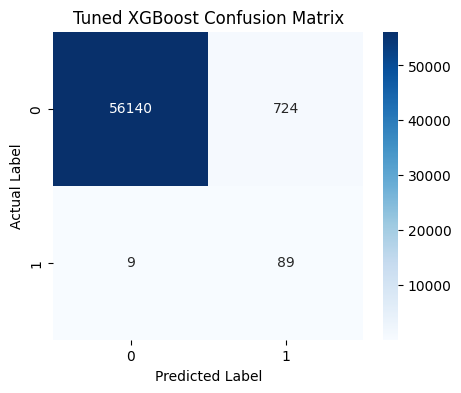

In [43]:
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues")
plt.title("Tuned XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [44]:
print("Tuned XGBoost Classification Report:")
print(classification_report(y_test, y_pred_best, zero_division=0))

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.11      0.91      0.20        98

    accuracy                           0.99     56962
   macro avg       0.55      0.95      0.59     56962
weighted avg       1.00      0.99      0.99     56962



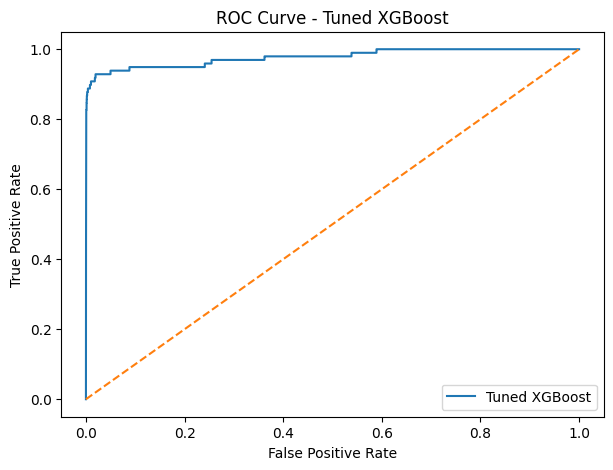

In [45]:
fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best)

plt.figure(figsize=(7, 5))
plt.plot(fpr_best, tpr_best, label="Tuned XGBoost")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned XGBoost")
plt.legend()
plt.show()

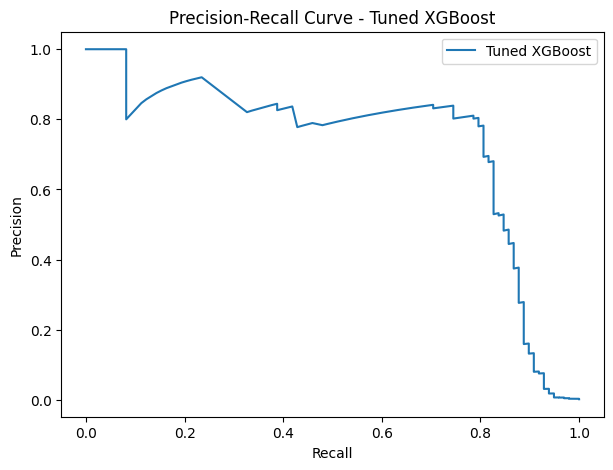

In [46]:
precision_best, recall_best, _ = precision_recall_curve(y_test, y_prob_best)

plt.figure(figsize=(7, 5))
plt.plot(recall_best, precision_best, label="Tuned XGBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Tuned XGBoost")
plt.legend()
plt.show()

# 10. Threshold Tuning

By default, XGBoost classifies a transaction as fraud when the predicted probability is greater than or equal to 0.5.

However, in fraud detection, the default threshold may not be optimal.

Lowering the threshold can increase recall and catch more fraud cases, but it may also increase false positives.

Threshold tuning allows the project to simulate real business trade-offs between fraud detection sensitivity and customer inconvenience.

In [47]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_best >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Precision,Recall,F1-Score
0,0.3,0.047053,0.928571,0.089567
1,0.4,0.073864,0.928571,0.136842
2,0.5,0.109471,0.908163,0.195390
3,0.6,0.160291,0.897959,0.272025
4,0.7,0.230159,0.887755,0.365546


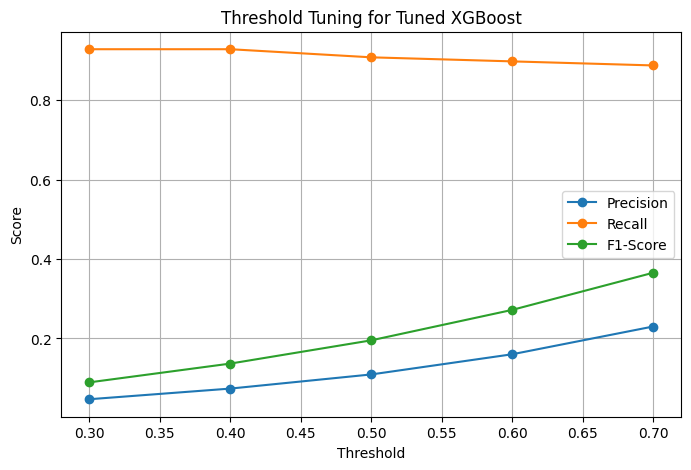

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1-Score"], marker="o", label="F1-Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning for Tuned XGBoost")
plt.legend()
plt.grid(True)
plt.show()

After observing the threshold tuning results, the most appropriate threshold can be selected based on project goals.

If the project prioritizes catching as many fraud cases as possible, a lower threshold with higher recall may be preferred.
If the project prioritizes reducing false alarms, a higher threshold may be selected.

# 11. Best Parameters and Final Choice

RandomizedSearchCV was used to explore a recall-focused XGBoost configuration. Although the tuned model achieved the highest recall, its precision and F1-score dropped substantially. Therefore, the scale_pos_weight version was selected as the final XGBoost candidate because it provided a stronger overall balance between recall, precision, F1-score, and PR-AUC.

In [49]:
# Model selection logic and final model assignment
xgb_candidates_df = pd.DataFrame([
    initial_results,
    weighted_results,
    smote_results,
    best_results
])

final_xgb_model = xgb_weighted
final_xgb_results = weighted_results
final_xgb_name = "XGBoost (scale_pos_weight)"

print("Best Hyperparameters:")
print(random_search.best_params_)

print("\nFinal Selected Model Performance:")
print(pd.DataFrame([final_xgb_results]))

Best Hyperparameters:
{'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Final Selected Model Performance:
                        Model  Accuracy  Precision    Recall  F1-Score  \
0  XGBoost (scale_pos_weight)  0.999526    0.88172  0.836735  0.858639   

    ROC-AUC    PR-AUC  
0  0.968238  0.880004  


Example interpretation:

The recall-optimized tuned XGBoost achieved the highest recall, but it also produced many false positives, leading to very low precision and F1-score. Among the XGBoost variants, the scale_pos_weight model provided the strongest overall balance and was therefore selected as the final XGBoost model for the project.

# 12. Save Best Model

The best XGBoost model is saved so that it can be reused in the following stages:

- Explainability with SHAP
- FastAPI backend integration
- Streamlit frontend deployment

In [50]:
os.makedirs("../models/final", exist_ok=True)
joblib.dump(final_xgb_model, "../models/final/best_xgboost_model.pkl")
joblib.dump(best_xgb_model, "../models/final/tuned_recall_xgboost_model.pkl")

print("Best XGBoost model saved successfully.")

Best XGBoost model saved successfully.


In [51]:
os.makedirs("../models/final", exist_ok=True)
joblib.dump(final_xgb_model, "../models/final/best_xgboost_model.pkl")
joblib.dump(best_xgb_model, "../models/final/tuned_recall_xgboost_model.pkl")

print("Best XGBoost model saved successfully.")

Best XGBoost model saved successfully.


In [52]:
os.makedirs("../reports/tables", exist_ok=True)

comparison_df.to_csv("../reports/tables/xgboost_comparison_results.csv", index=False)
threshold_df.to_csv("../reports/tables/xgboost_threshold_tuning.csv", index=False)

print("Evaluation tables saved successfully.")

Evaluation tables saved successfully.


Among the XGBoost variants, the scale_pos_weight model was selected as the final model for later explainability and deployment because it provided the strongest overall balance between recall, precision, F1-score, and PR-AUC.

In [53]:
# Model selection logic and final model assignment
xgb_candidates_df = pd.DataFrame([
    initial_results,
    weighted_results,
    smote_results,
    best_results
])

final_xgb_model = xgb_weighted
final_xgb_results = weighted_results
final_xgb_name = "XGBoost (scale_pos_weight)"